# Module 26 – Sales Forecasting Case Study

## Objective

In this case study, I will work with a sales dataset and try to predict future sales using a forecasting model. I will first explore the data, clean it, check the sales trend and seasonality, prepare the features, train a Linear Regression model, and evaluate the predictions using different metrics.

## 1. Importing the required libraries

First, I will import the libraries needed for this assignment. Pandas will help me work with the dataset, NumPy will be used for calculations, and Matplotlib and Seaborn will help me create graphs. I will also use Linear Regression and some evaluation metrics from scikit-learn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Loading the dataset

Now I will load the CSV file into a DataFrame. A DataFrame makes it easier to view, clean, and analyse the data.

In [3]:
df = pd.read_csv('train.csv')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## 3. Understanding the dataset

Before doing any preprocessing, I will check the number of rows and columns, the column names, and the data types. This will help me understand what kind of information is available in the dataset.

In [4]:
print('Number of rows and columns:', df.shape)

print('\nColumn names:')
print(df.columns.tolist())

print('\nData types:')
print(df.dtypes)

Number of rows and columns: (9800, 18)

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

Data types:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object


## 4. Checking missing values

Next, I will check whether any columns contain missing values. Missing values can create problems during analysis and model training, so I need to identify them before continuing.

In [5]:
missing_values = df.isnull().sum()
print(missing_values)

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


The missing values are in the Postal Code column. This column is not needed for this forecasting task, so I will remove it. I will then check the missing values again.

In [6]:
if 'Postal Code' in df.columns:
    df = df.drop(columns=['Postal Code'])

print('Missing values after handling:')
print(df.isnull().sum())

Missing values after handling:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64


## 5. Checking duplicate records

I will check for duplicate rows because duplicate records can affect the total sales and may give misleading results.

In [7]:
print('Number of duplicate rows:', df.duplicated().sum())

df = df.drop_duplicates()

print('Shape after removing duplicates:', df.shape)

Number of duplicate rows: 0
Shape after removing duplicates: (9800, 17)


## 6. Converting the date column

The Order Date column needs to be converted into datetime format. This will allow me to extract the year, month, day, and day of the week.

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

print(df['Order Date'].head())
print('\nData type:', df['Order Date'].dtype)

0   2017-11-08
1   2017-11-08
2   2017-06-12
3   2016-10-11
4   2016-10-11
Name: Order Date, dtype: datetime64[us]

Data type: datetime64[us]


## 7. Sorting the data by date

Since this is a forecasting problem, the order of the dates is important. I will sort the dataset from the earliest date to the latest date.

In [9]:
df = df.sort_values('Order Date')
df = df.reset_index(drop=True)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,7981,CA-2015-103800,2015-01-03,07/01/2015,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448
1,742,CA-2015-112326,2015-01-04,08/01/2015,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540
2,741,CA-2015-112326,2015-01-04,08/01/2015,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736
3,740,CA-2015-112326,2015-01-04,08/01/2015,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784
4,1760,CA-2015-141817,2015-01-05,12/01/2015,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536


## 8. Basic statistical analysis

Now I will look at basic statistics for the numerical columns. I will also calculate the total sales, average sales per order, and the minimum and maximum sales values.

In [10]:
df.describe()

,Row ID,Order Date,Sales
count,9800.000000,9800,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469,230.769059
min,1.000000,2015-01-03 00:00:00,0.444000
25%,2450.750000,2016-05-24 00:00:00,17.248000
50%,4900.500000,2017-06-26 00:00:00,54.490000
75%,7350.250000,2018-05-15 00:00:00,210.605000
max,9800.000000,2018-12-30 00:00:00,22638.480000
std,2829.160653,NaN,626.651875


In [11]:
print('Total sales:', df['Sales'].sum())
print('Average sales per order:', df['Sales'].mean())
print('Minimum sales:', df['Sales'].min())
print('Maximum sales:', df['Sales'].max())

Total sales: 2261536.7827000003
Average sales per order: 230.7690594591837
Minimum sales: 0.444
Maximum sales: 22638.48


## 9. Extracting date features

I will create new columns from the order date. These features will help me understand sales patterns across different years, months, days, and weekdays.

In [12]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day
df['DayOfWeek'] = df['Order Date'].dt.dayofweek

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Day,DayOfWeek
0,7981,CA-2015-103800,2015-01-03,07/01/2015,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2015,1,3,5
1,742,CA-2015-112326,2015-01-04,08/01/2015,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2015,1,4,6
2,741,CA-2015-112326,2015-01-04,08/01/2015,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,2015,1,4,6
3,740,CA-2015-112326,2015-01-04,08/01/2015,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,2015,1,4,6
4,1760,CA-2015-141817,2015-01-05,12/01/2015,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,2015,1,5,0


## 10. Exploring sales by year

I will calculate the total sales for each year. This will help me understand whether sales are increasing or decreasing over time.

In [13]:
yearly_sales = df.groupby('Year')['Sales'].sum()
print(yearly_sales)

Year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64


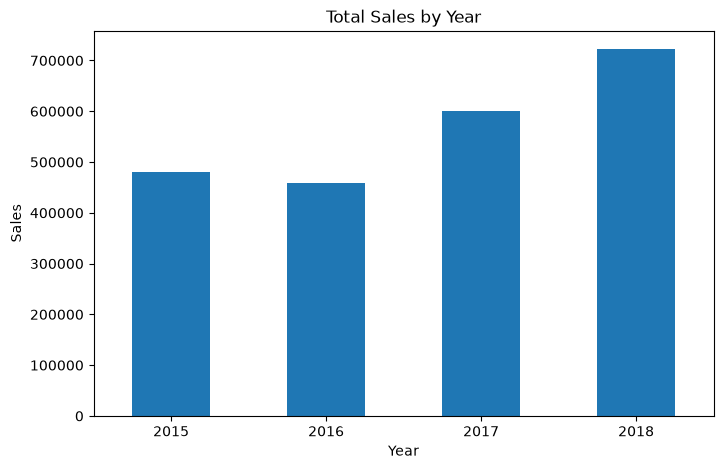

In [14]:
plt.figure(figsize=(8, 5))
yearly_sales.plot(kind='bar')
plt.title('Total Sales by Year')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.show()

## 11. Exploring sales by month

Now I will calculate total sales for each month. This will give me an initial idea about which months have higher or lower sales.

In [15]:
monthly_sales_by_month = df.groupby('Month')['Sales'].sum()
print(monthly_sales_by_month)

Month
1      94291.6296
2      59371.1154
3     197573.5872
4     136283.0006
5     154086.7237
6     145837.5233
7     145535.6890
8     157315.9270
9     300103.4117
10    199496.2947
11    350161.7110
12    321480.1695
Name: Sales, dtype: float64


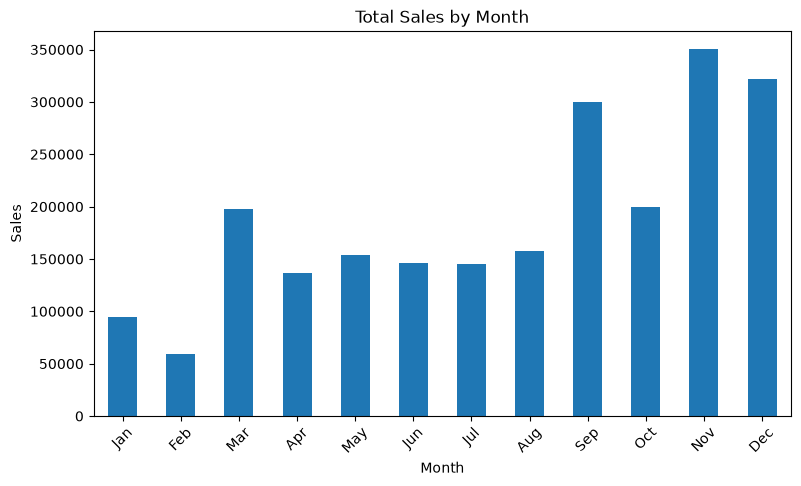

In [16]:
plt.figure(figsize=(9, 5))
monthly_sales_by_month.plot(kind='bar')
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(
    range(12),
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    rotation=45
)
plt.show()

## 12. Creating monthly sales data

The dataset contains individual order records. For forecasting, I will group the sales by month and calculate the total sales for each month.

In [17]:
monthly_data = df.set_index('Order Date')['Sales'].resample('MS').sum()
monthly_data = monthly_data.reset_index()
monthly_data.columns = ['Date', 'Sales']

monthly_data.head()

,Date,Sales
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


## 13. Checking the monthly sales data

I will check the shape of the monthly dataset, missing values, and the date range.

In [18]:
print('Shape of monthly data:', monthly_data.shape)

print('\nMissing values:')
print(monthly_data.isnull().sum())

print('\nDate range:')
print(monthly_data['Date'].min())
print(monthly_data['Date'].max())

Shape of monthly data: (48, 2)

Missing values:
Date     0
Sales    0
dtype: int64

Date range:
2015-01-01 00:00:00
2018-12-01 00:00:00


## 14. Plotting the monthly sales trend

This line graph will help me see how sales change over time. I can use it to identify an overall trend and possible seasonal changes.

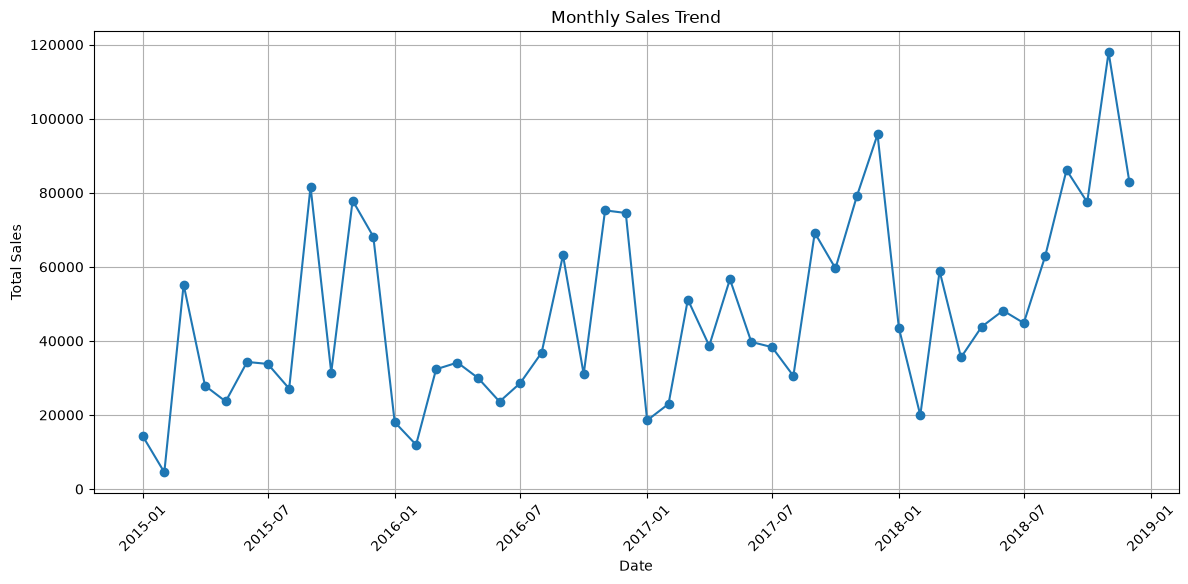

In [19]:
plt.figure(figsize=(14, 6))
plt.plot(monthly_data['Date'], monthly_data['Sales'], marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## 15. Preparing features for the model

I will use Year and Month as the input features for the Linear Regression model. The target variable will be the monthly Sales column.

In [22]:
monthly_data['Year'] = monthly_data['Date'].dt.year
monthly_data['Month'] = monthly_data['Date'].dt.month

X = monthly_data[['Year', 'Month']]
y = monthly_data['Sales']

## 16. Splitting the data into training and testing sets

Since this is a forecasting problem, I will not randomly shuffle the data. I will use the earlier 80 percent of the months for training and the later 20 percent for testing.

In [23]:
split_index = int(len(monthly_data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print('Training data shape:', X_train.shape)
print('Testing data shape:', X_test.shape)

Training data shape: (38, 2)
Testing data shape: (10, 2)


## 17. Training the Linear Regression model

Now I will create the Linear Regression model and train it using the training data. The model will learn the relationship between the year, month, and monthly sales.

In [24]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[5372.84,4816.6 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Year','Month']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.082e+07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


## 18. Making predictions

After training the model, I will use it to predict sales for the testing period. I will also create a table to compare actual sales and predicted sales.

In [25]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    'Date': monthly_data.loc[X_test.index, 'Date'].values,
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

comparison

,Date,Actual Sales,Predicted Sales
0,2018-03-01,58863.4128,36770.670002
1,2018-04-01,35541.9101,41587.266087
2,2018-05-01,43825.9822,46403.862172
3,2018-06-01,48190.7277,51220.458256
4,2018-07-01,44825.1040,56037.054341
5,2018-08-01,62837.8480,60853.650425
6,2018-09-01,86152.8880,65670.246510
7,2018-10-01,77448.1312,70486.842594
8,2018-11-01,117938.1550,75303.438679
9,2018-12-01,83030.3888,80120.034763


## 19. Evaluating the model

I will calculate MAE, RMSE, and R² score. MAE shows the average absolute prediction error. RMSE gives more importance to larger errors. R² shows how well the model explains the variation in sales.

In [26]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('Mean Absolute Error (MAE):', mae)
print('Root Mean Squared Error (RMSE):', rmse)
print('R² Score:', r2)

Mean Absolute Error (MAE): 11993.08576817159
Root Mean Squared Error (RMSE): 17217.12099644059
R² Score: 0.486300742183561


## 20. Plotting actual and predicted sales

This graph will help me compare the actual sales with the predictions made by the model.

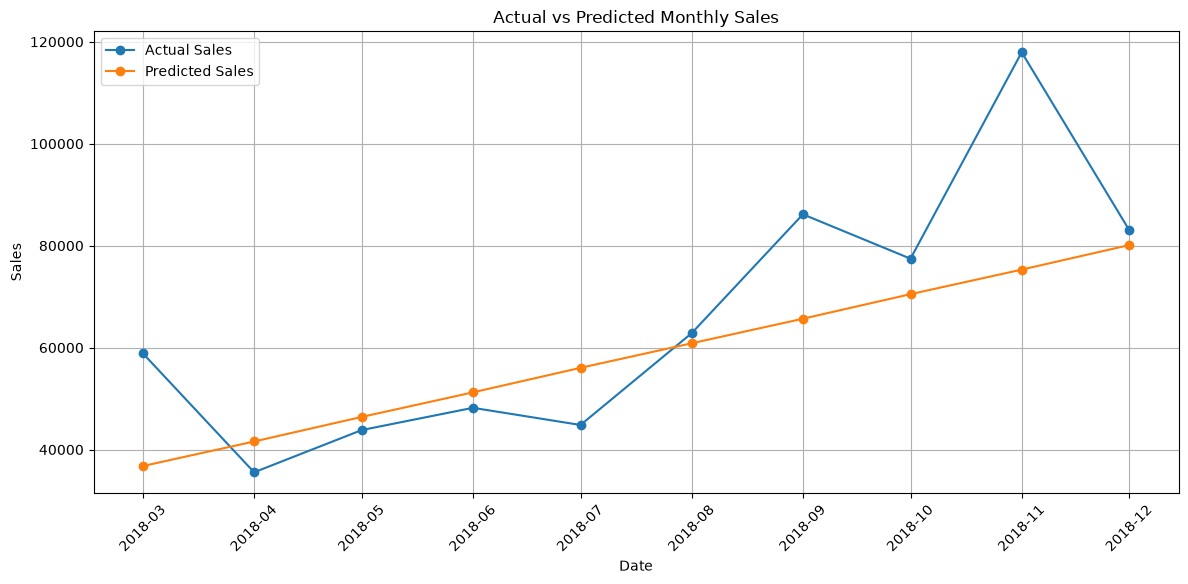

In [27]:
plt.figure(figsize=(14, 6))
plt.plot(comparison['Date'], comparison['Actual Sales'], marker='o', label='Actual Sales')
plt.plot(comparison['Date'], comparison['Predicted Sales'], marker='o', label='Predicted Sales')
plt.title('Actual vs Predicted Monthly Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

## 21. Checking the model coefficients

I will check the coefficients learned by the model. These values show how the model uses the Year and Month features to make predictions.

In [28]:
print('Year coefficient:', model.coef_[0])
print('Month coefficient:', model.coef_[1])
print('Intercept:', model.intercept_)

Year coefficient: 5372.840883219656
Month coefficient: 4816.596084532762
Intercept: -10820072.020588381


## 22. Predicting future monthly sales

As an additional forecasting step, I will predict sales for the six months after the last month available in the dataset. These values are estimates made by the model and are not actual recorded sales.

In [29]:
last_date = monthly_data['Date'].max()

future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=6,
    freq='MS'
)

future_data = pd.DataFrame({'Date': future_dates})
future_data['Year'] = future_data['Date'].dt.year
future_data['Month'] = future_data['Date'].dt.month

future_X = future_data[['Year', 'Month']]
future_data['Predicted Sales'] = model.predict(future_X)

future_data

,Date,Year,Month,Predicted Sales
0,2019-01-01,2019,1,32510.318717
1,2019-02-01,2019,2,37326.914801
2,2019-03-01,2019,3,42143.510886
3,2019-04-01,2019,4,46960.106970
4,2019-05-01,2019,5,51776.703055
5,2019-06-01,2019,6,56593.299139


## 24. Plotting the future forecast

I will plot the historical sales and the future predicted sales together so that I can see the expected direction of sales after the historical period.

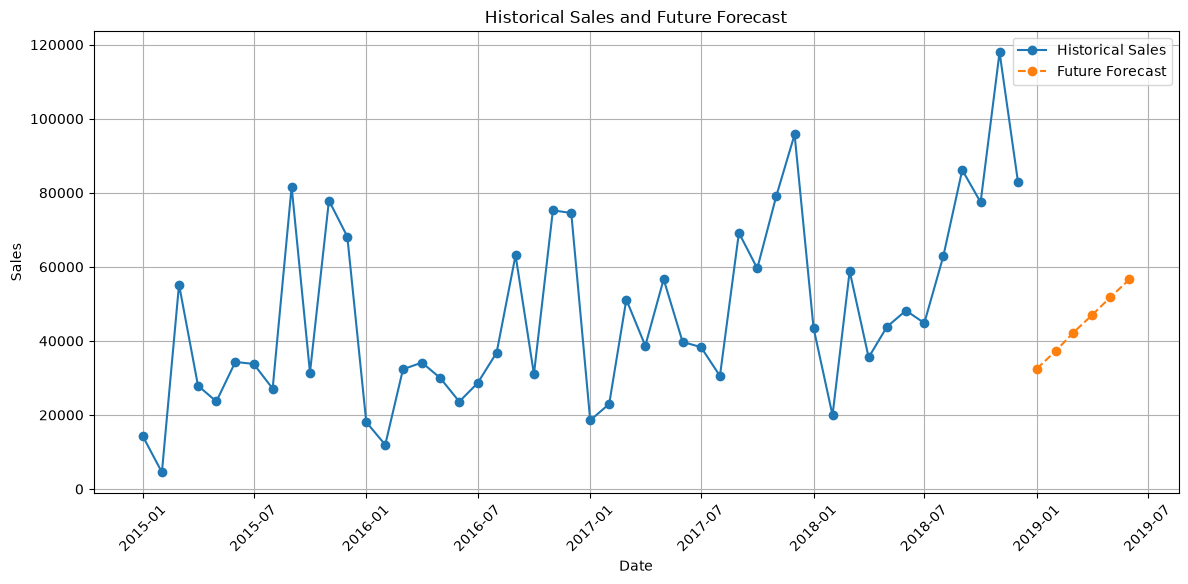

In [30]:
plt.figure(figsize=(14, 6))
plt.plot(monthly_data['Date'], monthly_data['Sales'], marker='o', label='Historical Sales')
plt.plot(future_data['Date'], future_data['Predicted Sales'], marker='o', linestyle='--', label='Future Forecast')
plt.title('Historical Sales and Future Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()



## Final Observations and Findings

In this case study, I used Linear Regression to forecast future monthly sales based on the historical sales data.

The model predicted the following sales for the first six months of 2019:

* January 2019: 32,510.32
* February 2019: 37,326.91
* March 2019: 42,143.51
* April 2019: 46,960.11
* May 2019: 51,776.70
* June 2019: 56,593.30

From these predictions, I observed that the model expects sales to increase every month. The predicted sales rise from approximately 32,510 in January to 56,593 in June.

This shows that the Linear Regression model has identified an increasing sales trend in the historical data. However, these are only predicted values, so actual future sales may be different.

Overall, this forecasting exercise helped me understand how historical sales data can be used to predict future sales and how machine learning models can support sales planning.


# Colab link

https://colab.research.google.com/drive/1MoF9bePddz0RFv8j46zV2sXTIP7uRNXQ?usp=sharing